# NB13 — Ocupação de Berços de Contentores · ANTAQ 2025

**Objetivo:** Avaliar taxa de saturação de berços em terminais de contentores, identificar berços  
críticos (>80% ocupação), padrão sazonal e correlação com TEstadia por porto.

**Datasets:** 2025_Taxa_Ocupacao · 2025_Taxa_Ocupacao_Com_Carga · Relatorio_Berco · 2025_Atracacao · 2025_Tempos_Atracacao  
**Estratégia de join:** TO → Atracacao via IDBerco (70% cobertura) → Porto/Terminal  
**Data de execução:** 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')

DATA_CAD  = '../data/01_Cadastros/'
DATA_OPER = '../data/02_Operacoes/'
DATA_IND  = '../data/03_Indicadores/'
FIG_DIR   = '../outputs/figures/'
CSV_DIR   = '../outputs/processed_data/'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

# ── Mapeamento de meses (pt abrev → número) ────────────────────────────────
MES_ORDER = {'jan':1,'fev':2,'mar':3,'abr':4,'mai':5,'jun':6,
             'jul':7,'ago':8,'set':9,'out':10,'nov':11,'dez':12}
MES_LABEL = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
             7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}

# ── Portos container (Porto Atracação em Atracacao) ────────────────────────
CONTAINER_PORTOS = {
    'Santos':                                        'Santos',
    'DP World Santos':                               'Santos',
    'Paranaguá':                                     'Paranaguá',
    'Rio de Janeiro':                                'Rio de Janeiro',
    'Suape':                                         'Suape',
    'Terminal Portuário do Pecém':                   'Pecém',
    'Rio Grande':                                    'Rio Grande',
    'Itajaí':                                        'Itajaí',
    'Portonave - Terminais Portuários de Navegantes':'Itajaí',
    'Porto Itapoá Terminais Portuários':             'Itajaí',
    'Itaguaí':                                       'Itaguaí',
    'São Francisco do Sul':                          'São Francisco do Sul',
    'Salvador':                                      'Salvador',
}

# ── Keywords de exclusão de terminais não-container ───────────────────────
EXCL_KEYWORDS = [
    'petróleo','petrobras','peta','petl','petrob','granel',
    'minério','fertiliz','alumina','estaleiro','offshore',
    'tanque','químic','passageiro','marinha','rebocad',
]

# ── Thresholds de saturação ────────────────────────────────────────────────
THRESH_AMARELO  = 60.0   # % ocupação
THRESH_VERMELHO = 80.0
THRESH_CRITICO  = 95.0

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Setup OK')

Setup OK


---
## Passo 0 — Carga dos Datasets

In [2]:
# ── 0.1 Taxa_Ocupacao ─────────────────────────────────────────────────────
to_raw = pd.read_csv(DATA_IND + '2025_Taxa_Ocupacao.csv',
                     encoding='utf-8-sig', sep=';')
tocc_raw = pd.read_csv(DATA_IND + '2025_Taxa_Ocupacao_Com_Carga.csv',
                       encoding='utf-8-sig', sep=';')

print(f'Taxa_Ocupacao: {len(to_raw):,} registos | {to_raw["IDBerco"].nunique()} berços')
print(f'Taxa_Ocupacao_Com_Carga: {len(tocc_raw):,} registos')
print(f'Meses cobertos: {sorted(to_raw["MêsTaxaOcupacao"].unique().tolist())}')
print()

# ── Diferença TO vs TOCC ─────────────────────────────────────────────────
print('=== TO vs TOCC — diferença metodológica ===')
print('Taxa_Ocupacao (TO):          tempo total em que o berço está ocupado (inclui esperas na atracação)')
print('Taxa_Ocupacao_Com_Carga (TOCC): tempo em que o berço está ocupado E há carga sendo operada')
print('Uso nesta análise: TO para saturação estrutural; TOCC como proxy de eficiência operacional')

Taxa_Ocupacao: 325,945 registos | 893 berços
Taxa_Ocupacao_Com_Carga: 325,945 registos
Meses cobertos: ['abr', 'ago', 'dez', 'fev', 'jan', 'jul', 'jun', 'mai', 'mar', 'nov', 'out', 'set']

=== TO vs TOCC — diferença metodológica ===
Taxa_Ocupacao (TO):          tempo total em que o berço está ocupado (inclui esperas na atracação)
Taxa_Ocupacao_Com_Carga (TOCC): tempo em que o berço está ocupado E há carga sendo operada
Uso nesta análise: TO para saturação estrutural; TOCC como proxy de eficiência operacional


In [3]:
# ── 0.2 Atracacao ─────────────────────────────────────────────────────────
atr_raw = pd.read_csv(DATA_OPER + '2025_Atracacao.csv',
                      encoding='utf-8-sig', sep=';', low_memory=False)
NAV_COL = [c for c in atr_raw.columns if 'Navega' in c][0]
print(f'Atracacao: {len(atr_raw):,} registos')
print(f'Coluna navegação: {NAV_COL!r}')

# ── 0.3 Tempos ─────────────────────────────────────────────────────────────
tem_raw = pd.read_csv(DATA_IND + '2025_Tempos_Atracacao.csv',
                      encoding='utf-8-sig', sep=';')
for col in ['TEsperaAtracacao', 'TEstadia']:
    tem_raw[col] = pd.to_numeric(
        tem_raw[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')
print(f'Tempos: {len(tem_raw):,} registos')

# ── 0.4 Relatorio_Berco ────────────────────────────────────────────────────
rb_raw = pd.read_csv(DATA_CAD + 'Relatorio_Berco.csv',
                     encoding='utf-8-sig', sep=';')
print(f'Relatorio_Berco: {len(rb_raw):,} berços')

Atracacao: 116,098 registos
Coluna navegação: 'Tipo de Navegação da Atracação'


Tempos: 116,098 registos
Relatorio_Berco: 875 berços


---
## Passo 1 — Pré-processamento Taxa_Ocupacao

In [4]:
# ── 1.1 Calcular taxa diária (%) ──────────────────────────────────────────
to = to_raw.copy()
to['taxa_pct']      = to['TempoEmMinutosdias']                           / 1440 * 100
to['taxa_carga_pct'] = tocc_raw['TempoEmMinutosdiasFlagCarga']           / 1440 * 100
to['mes_num']       = to['MêsTaxaOcupacao'].str.lower().map(MES_ORDER)

# ── Verificar taxa > 100% ─────────────────────────────────────────────────
n_over100 = (to['taxa_pct'] > 100).sum()
n_over100_carga = (to['taxa_carga_pct'] > 100).sum()
lbl0 = 'ATENÇÃO' if n_over100 > 0 else 'OK'
print(f'Registos taxa_pct > 100%: {n_over100}  ← {lbl0}')
lbl1 = 'ATENÇÃO' if n_over100_carga > 0 else 'OK'
print(f'Registos taxa_carga_pct > 100%: {n_over100_carga}  ← {lbl1}')
if n_over100 > 0:
    print('Amostras com taxa > 100% (possível sobreposição de registos):')
    print(to[to['taxa_pct'] > 100].head(5))
print()
print(f'Total registos: {len(to):,}')
print(f'Berços únicos: {to["IDBerco"].nunique()}')
print(f'taxa_pct média geral: {to["taxa_pct"].mean():.1f}%  mediana: {to["taxa_pct"].median():.1f}%')

Registos taxa_pct > 100%: 0  ← OK
Registos taxa_carga_pct > 100%: 0  ← OK

Total registos: 325,945
Berços únicos: 893
taxa_pct média geral: 31.9%  mediana: 0.0%


---
## Passo 2 — Join com Atracacao (bridge para Porto/Terminal)

In [5]:
# ── 2.1 Mapeamento IDBerco → Porto/Terminal via Atracacao ─────────────────
# Estratégia: Relatorio_Berco usa formato diferente de IDBerco.
# Atracacao tem IDBerco no mesmo formato de Taxa_Ocupacao (ex: SSZ0651, BRRJ0055004).
# Usamos Atracacao como bridge: IDBerco → Porto Atracação + Terminal

berco_map = (
    atr_raw.groupby('IDBerco')
    .agg(
        Porto=('Porto Atracação', lambda x: x.mode()[0] if len(x) > 0 else np.nan),
        Terminal=('Terminal',     lambda x: x.mode()[0] if len(x) > 0 else np.nan),
    )
    .reset_index()
)

# Join Relatorio_Berco (para Nome do Berço)
rb_slim = rb_raw[['Código do Berço', 'Nome do Berço']].rename(
    columns={'Código do Berço': 'IDBerco', 'Nome do Berço': 'Nome_Berco'})
berco_map = berco_map.merge(rb_slim, on='IDBerco', how='left')
# Fallback: se Nome_Berco não disponível, usar Terminal como nome
berco_map['Nome_Berco'] = berco_map['Nome_Berco'].fillna(berco_map['Terminal'])

# Join TO × berco_map
to = to.merge(berco_map, on='IDBerco', how='left')

n_with_porto = to['Porto'].notna().sum()
pct_match = n_with_porto / len(to) * 100
print(f'TO registos com Porto identificado: {n_with_porto:,} de {len(to):,} ({pct_match:.1f}%)')
print(f'TO registos sem Porto (IDBerco não aparece em Atracacao): {len(to) - n_with_porto:,}')

TO registos com Porto identificado: 228,125 de 326,310 (69.9%)
TO registos sem Porto (IDBerco não aparece em Atracacao): 98,185


---
## Passo 3 — Filtro Berços de Contentores

In [6]:
# ── 3.1 Filtrar portos container ──────────────────────────────────────────
n_bercos_before = to['IDBerco'].nunique()
n_reg_before    = len(to)

to['Porto_Canon'] = to['Porto'].map(CONTAINER_PORTOS)
to_cnt = to[to['Porto_Canon'].notna()].copy()

# ── 3.2 Excluir terminais não-container por keyword ───────────────────────
def is_non_container(terminal_name):
    if pd.isna(terminal_name):
        return False
    tn = str(terminal_name).lower()
    return any(kw in tn for kw in EXCL_KEYWORDS)

mask_excl = to_cnt['Terminal'].apply(is_non_container)
to_excl   = to_cnt[mask_excl]  # para log
to_cnt    = to_cnt[~mask_excl].copy()

n_bercos_after = to_cnt['IDBerco'].nunique()
n_reg_after    = len(to_cnt)

print(f'Registos antes do filtro container:  {n_reg_before:,}  ({n_bercos_before} berços)')
print(f'Terminais excluídos por keyword:      {to_excl["IDBerco"].nunique()} berços')
print(f'Registos após filtro container:       {n_reg_after:,}  ({n_bercos_after} berços)')
print()
print('Berços por porto canonico:')
print(to_cnt.groupby('Porto_Canon')['IDBerco'].nunique().sort_values(ascending=False))
print()
print('Amostra terminais excluídos por keyword (top 10):')
print(to_excl.groupby('Terminal')['IDBerco'].first().head(10).reset_index()[['Terminal','IDBerco']].to_string(index=False))

Registos antes do filtro container:  326,310  (893 berços)
Terminais excluídos por keyword:      7 berços
Registos após filtro container:       58,765  (161 berços)

Berços por porto canonico:
Porto_Canon
Santos                  55
Rio de Janeiro          24
Rio Grande              19
Paranaguá               14
Suape                   11
Itajaí                   9
Salvador                 8
Pecém                    8
São Francisco do Sul     7
Itaguaí                  6
Name: IDBerco, dtype: int64

Amostra terminais excluídos por keyword (top 10):
                 Terminal IDBerco
Corredor de Fertilizantes PNG0208
                Petrobrás RIO5064


---
## Passo 4 — Nº Atracações por Berço (LC + Cabotagem)

In [7]:
# ── Atracações LC+Cab por berço, com TEstadia ─────────────────────────────
atr_lccab = atr_raw[atr_raw[NAV_COL].isin(['Longo Curso', 'Cabotagem'])].copy()
atr_lccab = atr_lccab.merge(tem_raw[['IDAtracacao','TEstadia','TEsperaAtracacao']],
                             on='IDAtracacao', how='left')

berco_atr = (
    atr_lccab.groupby('IDBerco')
    .agg(
        N_Atr=('IDAtracacao', 'count'),
        TEstadia_Med=('TEstadia', 'median'),
        TEspera_Med=('TEsperaAtracacao', 'median'),
    )
    .reset_index()
)
# Mínimo 20 obs para TEstadia mediana ser válida
berco_atr.loc[berco_atr['N_Atr'] < 20, ['TEstadia_Med','TEspera_Med']] = np.nan

print(f'Berços com atracações LC+Cab: {len(berco_atr)}')

Berços com atracações LC+Cab: 434


---
## Parte 1 — Ocupação Média por Berço

In [8]:
# ── KPIs anuais por berço ─────────────────────────────────────────────────
berco_kpi_rows = []
for berco_id, grp in to_cnt.groupby('IDBerco'):
    taxa_media = grp['taxa_pct'].mean()
    taxa_carga_media = grp['taxa_carga_pct'].mean()
    taxa_max_mensal = grp.groupby('mes_num')['taxa_pct'].mean().max()
    dias_80  = (grp['taxa_pct'] > THRESH_VERMELHO).sum()
    dias_95  = (grp['taxa_pct'] > THRESH_CRITICO).sum()
    mes_pico_num = grp.groupby('mes_num')['taxa_pct'].mean().idxmax()
    porto  = grp['Porto_Canon'].iloc[0]
    nome   = grp['Nome_Berco'].iloc[0] if 'Nome_Berco' in grp.columns else berco_id
    terminal = grp['Terminal'].iloc[0] if 'Terminal' in grp.columns else ''

    if taxa_media < THRESH_AMARELO:
        status = 'Verde'
    elif taxa_media < THRESH_VERMELHO:
        status = 'Amarelo'
    else:
        status = 'Vermelho'

    berco_kpi_rows.append({
        'IDBerco': berco_id,
        'Nome_Berco': nome,
        'Terminal': terminal,
        'Porto': porto,
        'Taxa_Media_Pct': round(taxa_media, 1),
        'Taxa_Carga_Media_Pct': round(taxa_carga_media, 1),
        'Taxa_Max_Mensal_Pct': round(taxa_max_mensal, 1),
        'Dias_Acima_80': int(dias_80),
        'Dias_Acima_95': int(dias_95),
        'Mes_Pico': MES_LABEL.get(mes_pico_num, str(mes_pico_num)),
        'Status': status,
        'N_Dias': len(grp),
    })

berco_kpi = pd.DataFrame(berco_kpi_rows).sort_values('Taxa_Media_Pct', ascending=False)
berco_kpi = berco_kpi.merge(berco_atr[['IDBerco','N_Atr','TEstadia_Med','TEspera_Med']],
                             on='IDBerco', how='left')

print('Distribuição de status:')
print(berco_kpi['Status'].value_counts())
print()
print('Por porto:')
print(berco_kpi.groupby('Porto')['Status'].value_counts().unstack(fill_value=0))

Distribuição de status:
Status
Verde       79
Amarelo     47
Vermelho    35
Name: count, dtype: int64

Por porto:
Status                Amarelo  Verde  Vermelho
Porto                                         
Itaguaí                     2      3         1
Itajaí                      2      5         2
Paranaguá                   1      3        10
Pecém                       3      3         2
Rio Grande                  6     12         1
Rio de Janeiro              5     19         0
Salvador                    0      8         0
Santos                     22     20        13
Suape                       6      4         1
São Francisco do Sul        0      2         5


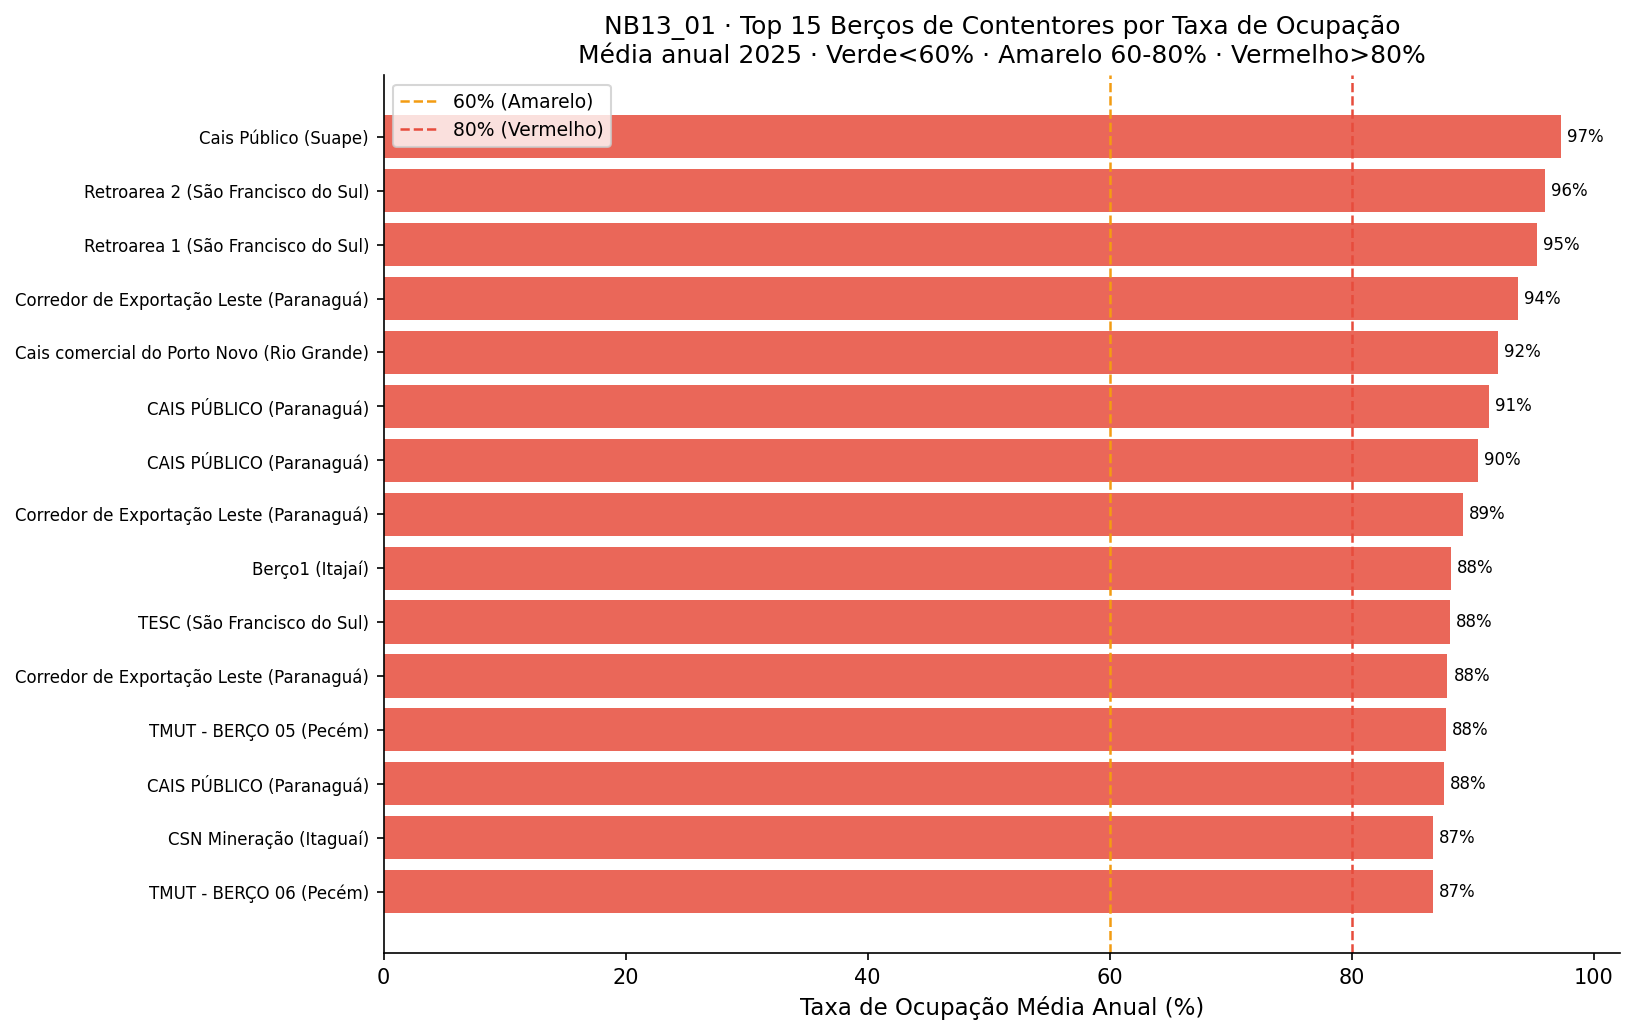

Salvo: nb13_01_ranking_bercos_ocupacao.png


In [9]:
# ── Figura nb13_01: Ranking berços saturados ──────────────────────────────
top15 = berco_kpi.head(15).copy()
top15['Label'] = top15['Nome_Berco'].str[:30] + ' (' + top15['Porto'] + ')'

STATUS_COLORS = {'Verde': '#2ecc71', 'Amarelo': '#f39c12', 'Vermelho': '#e74c3c'}
cores_bar = [STATUS_COLORS[s] for s in top15['Status']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(range(len(top15)), top15['Taxa_Media_Pct'], color=cores_bar, alpha=0.85)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Label'], fontsize=8)
ax.invert_yaxis()

# Threshold lines
ax.axvline(THRESH_AMARELO,  color='#f39c12', ls='--', lw=1.2, label=f'{THRESH_AMARELO:.0f}% (Amarelo)')
ax.axvline(THRESH_VERMELHO, color='#e74c3c', ls='--', lw=1.2, label=f'{THRESH_VERMELHO:.0f}% (Vermelho)')

# Anotar valor
for idx, val in enumerate(top15['Taxa_Media_Pct']):
    ax.text(val + 0.5, idx, f'{val:.0f}%', va='center', fontsize=8)

ax.set_xlabel('Taxa de Ocupação Média Anual (%)', fontsize=11)
ax.set_title('NB13_01 · Top 15 Berços de Contentores por Taxa de Ocupação\n'
             'Média anual 2025 · Verde<60% · Amarelo 60-80% · Vermelho>80%', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb13_01_ranking_bercos_ocupacao.png', dpi=150)
plt.show()
print('Salvo: nb13_01_ranking_bercos_ocupacao.png')

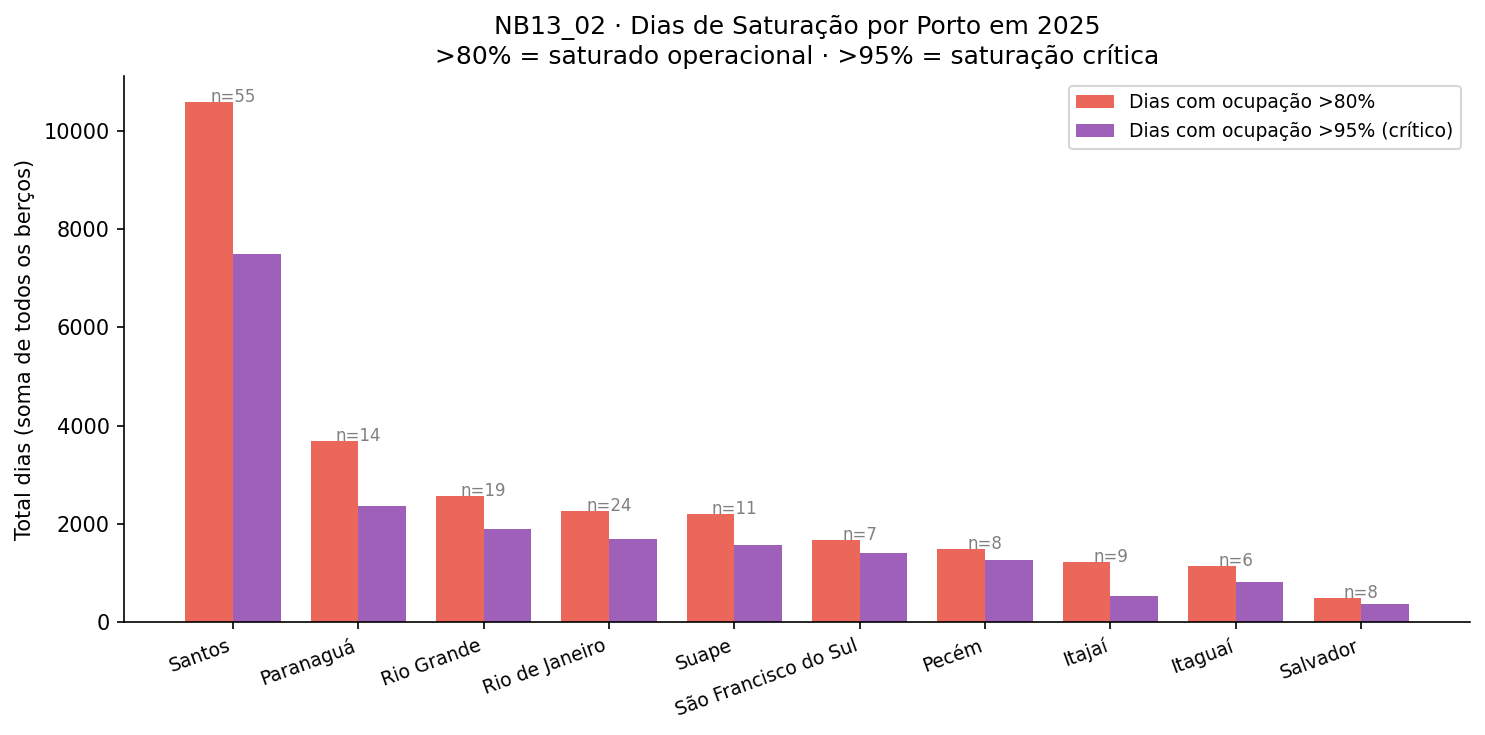

Salvo: nb13_02_dias_saturados_porto.png


In [10]:
# ── Figura nb13_02: Nº dias saturados (>80%) por porto ───────────────────
dias_saturados = (
    berco_kpi.groupby('Porto')
    .agg(
        Dias_Acima_80=('Dias_Acima_80','sum'),
        Dias_Acima_95=('Dias_Acima_95','sum'),
        N_Bercos=('IDBerco','count'),
        Taxa_Media=('Taxa_Media_Pct','mean')
    )
    .reset_index()
    .sort_values('Dias_Acima_80', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
x_d = np.arange(len(dias_saturados))
w   = 0.38
ax.bar(x_d - w/2, dias_saturados['Dias_Acima_80'], w,
       label='Dias com ocupação >80%', color='#e74c3c', alpha=0.85)
ax.bar(x_d + w/2, dias_saturados['Dias_Acima_95'], w,
       label='Dias com ocupação >95% (crítico)', color='#8e44ad', alpha=0.85)
ax.set_xticks(x_d)
ax.set_xticklabels(dias_saturados['Porto'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Total dias (soma de todos os berços)', fontsize=10)
ax.set_title('NB13_02 · Dias de Saturação por Porto em 2025\n'
             '>80% = saturado operacional · >95% = saturação crítica', fontsize=12)
ax.legend(fontsize=9)

# Anotar N berços
for idx, row in dias_saturados.reset_index(drop=True).iterrows():
    ax.text(idx, dias_saturados['Dias_Acima_80'].iloc[idx] + 2,
            f"n={int(row['N_Bercos'])}", ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(FIG_DIR + 'nb13_02_dias_saturados_porto.png', dpi=150)
plt.show()
print('Salvo: nb13_02_dias_saturados_porto.png')

---
## Parte 2 — Padrão Mensal de Saturação por Porto

In [11]:
# ── Ocupação mensal por porto ─────────────────────────────────────────────
mensal_porto = (
    to_cnt.groupby(['Porto_Canon', 'mes_num'])['taxa_pct']
    .mean()
    .reset_index()
    .rename(columns={'taxa_pct': 'taxa_media_mensal'})
)
mensal_porto['mes_label'] = mensal_porto['mes_num'].map(MES_LABEL)

# Coeficiente de variação por porto
cv_porto = (
    mensal_porto.groupby('Porto_Canon')['taxa_media_mensal']
    .agg(media_anual='mean', std_mensal='std')
    .assign(CV=lambda x: x['std_mensal'] / x['media_anual'] * 100)
    .reset_index()
    .sort_values('CV', ascending=False)
)
print('Coeficiente de Variação mensal por porto (CV alto = sazonalidade pronunciada):')
print(cv_porto.round(1).to_string(index=False))

Coeficiente de Variação mensal por porto (CV alto = sazonalidade pronunciada):
         Porto_Canon  media_anual  std_mensal   CV
            Salvador         24.4         6.5 26.6
          Rio Grande         45.6         5.5 12.1
             Itaguaí         60.7         7.2 11.9
              Itajaí         45.1         4.6 10.2
           Paranaguá         77.0         7.3  9.5
               Pecém         61.2         5.5  9.0
      Rio de Janeiro         36.7         3.3  9.0
              Santos         60.6         4.8  7.9
               Suape         65.7         5.1  7.7
São Francisco do Sul         68.9         4.9  7.1


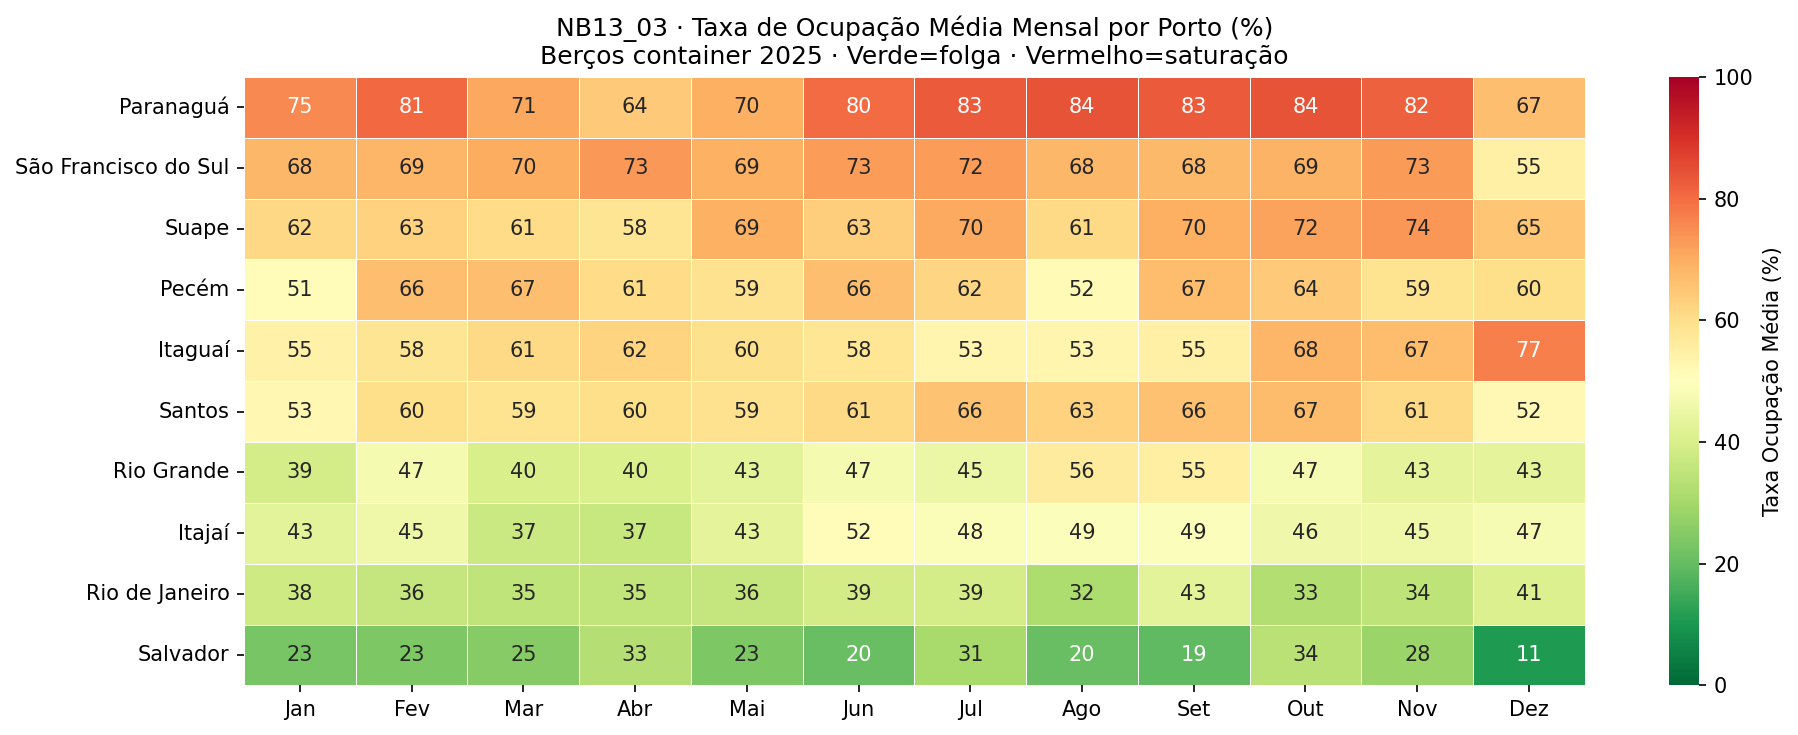

Salvo: nb13_03_heatmap_porto_mes_ocupacao.png


In [12]:
# ── Figura nb13_03: Heatmap porto × mês ──────────────────────────────────
pivot_mensal = mensal_porto.pivot(index='Porto_Canon', columns='mes_num',
                                  values='taxa_media_mensal')
pivot_mensal.columns = [MES_LABEL[c] for c in pivot_mensal.columns]

# Ordenar portos por taxa média anual
porto_order_tax = berco_kpi.groupby('Porto')['Taxa_Media_Pct'].mean().sort_values(ascending=False).index.tolist()
pivot_mensal = pivot_mensal.reindex([p for p in porto_order_tax if p in pivot_mensal.index])

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    pivot_mensal, annot=True, fmt='.0f', cmap='RdYlGn_r',
    vmin=0, vmax=100, linewidths=0.4, linecolor='white',
    ax=ax, cbar_kws={'label': 'Taxa Ocupação Média (%)'}
)
ax.set_title('NB13_03 · Taxa de Ocupação Média Mensal por Porto (%)\n'
             'Berços container 2025 · Verde=folga · Vermelho=saturação', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb13_03_heatmap_porto_mes_ocupacao.png', dpi=150)
plt.show()
print('Salvo: nb13_03_heatmap_porto_mes_ocupacao.png')

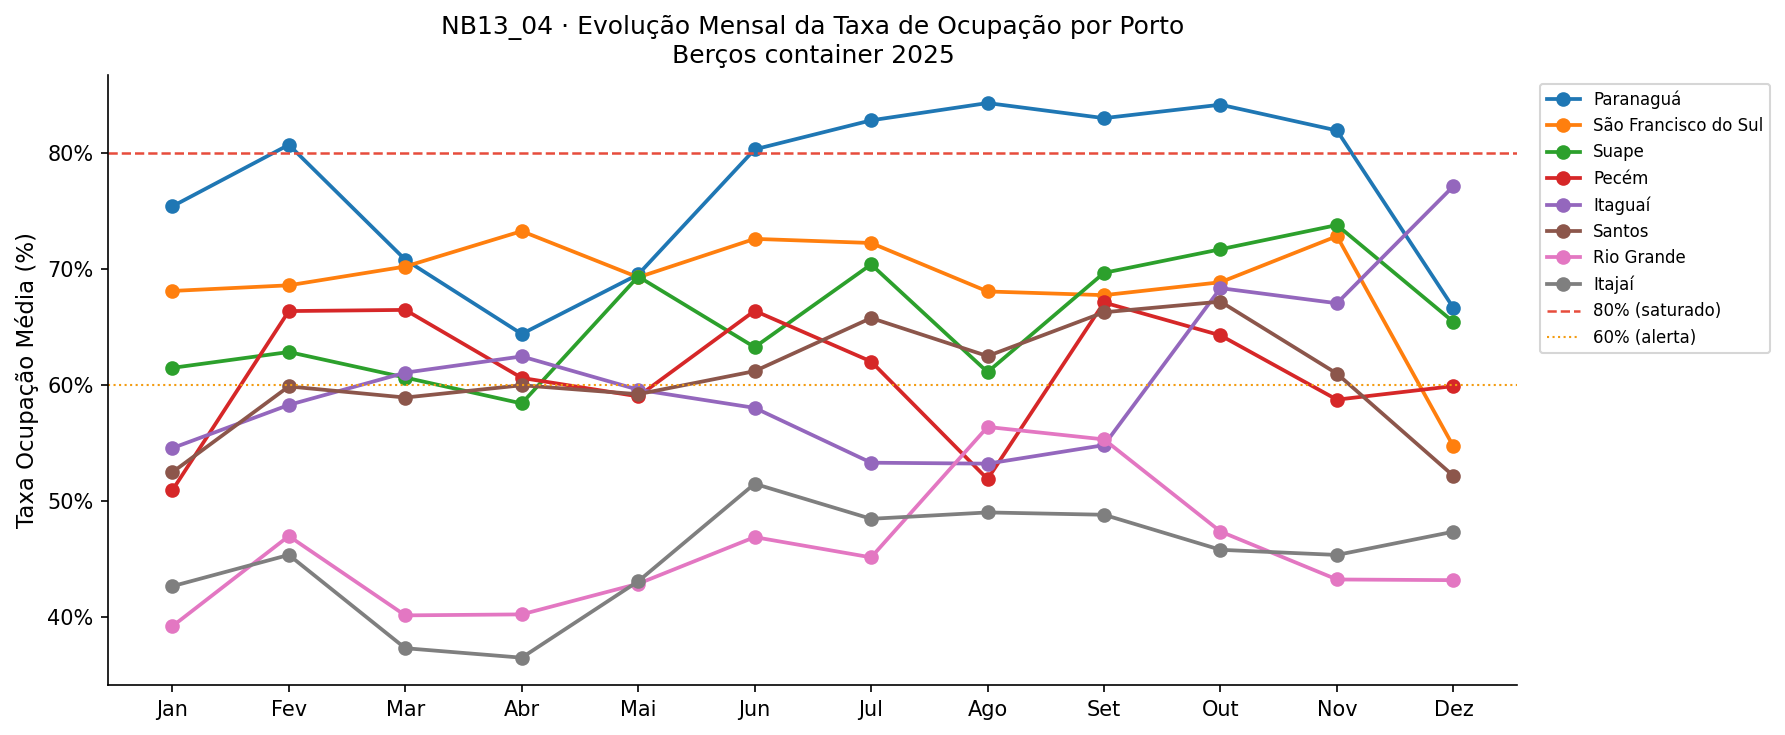

Salvo: nb13_04_evolucao_mensal_porto.png


In [13]:
# ── Figura nb13_04: Evolução mensal — linha por porto ─────────────────────
portos_plot = porto_order_tax[:8]  # top 8 por saturação
cmap_lines = plt.cm.tab10

fig, ax = plt.subplots(figsize=(12, 5))
for i_p, porto in enumerate(portos_plot):
    sub = mensal_porto[mensal_porto['Porto_Canon'] == porto].sort_values('mes_num')
    if len(sub) < 2:
        continue
    ax.plot(sub['mes_num'], sub['taxa_media_mensal'],
            marker='o', linewidth=1.8, label=porto, color=cmap_lines(i_p / 10))

ax.axhline(THRESH_VERMELHO, color='#e74c3c', ls='--', lw=1.2, label=f'{THRESH_VERMELHO:.0f}% (saturado)')
ax.axhline(THRESH_AMARELO,  color='#f39c12', ls=':',  lw=1.0, label=f'{THRESH_AMARELO:.0f}% (alerta)')
ax.set_xticks(list(MES_LABEL.keys()))
ax.set_xticklabels(list(MES_LABEL.values()))
ax.set_ylabel('Taxa Ocupação Média (%)', fontsize=11)
ax.set_title('NB13_04 · Evolução Mensal da Taxa de Ocupação por Porto\n'
             'Berços container 2025', fontsize=12)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb13_04_evolucao_mensal_porto.png', dpi=150)
plt.show()
print('Salvo: nb13_04_evolucao_mensal_porto.png')

---
## Parte 3 — Correlação Saturação × TEstadia

In [14]:
# ── TEstadia e TEspera mediana por porto (LC) ─────────────────────────────
atr_lc = atr_raw[atr_raw[NAV_COL] == 'Longo Curso'].copy()
atr_lc = atr_lc.merge(tem_raw[['IDAtracacao','TEstadia','TEsperaAtracacao']],
                       on='IDAtracacao', how='left')
porto_tempos = (
    atr_lc.groupby('Porto Atracação')
    .agg(
        TEstadia_Med=('TEstadia', 'median'),
        TEspera_Med=('TEsperaAtracacao', 'median'),
        N_Atr=('IDAtracacao', 'count'),
    )
    .reset_index()
)

# Mapear Porto Atracação → Porto_Canon
porto_tempos['Porto_Canon'] = porto_tempos['Porto Atracação'].map(CONTAINER_PORTOS)
porto_tempos_cnt = porto_tempos[porto_tempos['Porto_Canon'].notna()]

# Agregar por Porto_Canon (ex: Santos + DP World Santos)
porto_tempos_agg = (
    porto_tempos_cnt.groupby('Porto_Canon')
    .apply(lambda g: pd.Series({
        'TEstadia_Med':  np.average(g['TEstadia_Med'], weights=g['N_Atr']),
        'TEspera_Med':   np.average(g['TEspera_Med'], weights=g['N_Atr']),
        'N_Atr':         g['N_Atr'].sum(),
    }))
    .reset_index()
)

# Taxa ocupação média por porto
porto_taxa = berco_kpi.groupby('Porto')['Taxa_Media_Pct'].mean().reset_index()
porto_taxa.columns = ['Porto_Canon', 'Taxa_Media_Pct']

# Merge
corr_df = porto_taxa.merge(porto_tempos_agg, on='Porto_Canon', how='inner')
print(f'Portos na análise de correlação: {len(corr_df)}')
print(corr_df[['Porto_Canon','Taxa_Media_Pct','TEstadia_Med','TEspera_Med','N_Atr']].round(1).to_string(index=False))

Portos na análise de correlação: 10
         Porto_Canon  Taxa_Media_Pct  TEstadia_Med  TEspera_Med  N_Atr
             Itaguaí            60.7          77.3         17.6  578.0
              Itajaí            45.1          31.0         10.8 1366.0
           Paranaguá            77.0          98.2         58.3 2216.0
               Pecém            61.1          87.0         26.7  385.0
          Rio Grande            45.6          62.4         17.8  954.0
      Rio de Janeiro            36.7          24.1          1.0 1135.0
            Salvador            24.4          30.1          2.2  331.0
              Santos            60.6          75.8         23.7 4600.0
               Suape            65.7          54.6          6.1  514.0
São Francisco do Sul            68.9         239.6        163.3  409.0


In [15]:
# ── Correlação de Spearman ─────────────────────────────────────────────────
n_corr = len(corr_df)
if n_corr >= 4:
    rho_est,  p_est  = stats.spearmanr(corr_df['Taxa_Media_Pct'], corr_df['TEstadia_Med'])
    rho_esp,  p_esp  = stats.spearmanr(corr_df['Taxa_Media_Pct'], corr_df['TEspera_Med'])
    print(f'=== Correlação Spearman (n={n_corr} portos) ===')
    print(f'  Taxa_Ocupacao × TEstadia_Med:          ρ={rho_est:+.3f}  p={p_est:.3f}')
    print(f'  Taxa_Ocupacao × TEsperaAtracacao_Med:  ρ={rho_esp:+.3f}  p={p_esp:.3f}')
    print()
    print(f'NOTA: n={n_corr} é amostra pequena. Correlações indicativas, não conclusivas.')
    print('Interpretação requer cautela — ver limitações.')
else:
    print(f'Insuficiente: apenas {n_corr} portos com dados cruzados. Análise de correlação não executada.')
    rho_est = rho_esp = p_est = p_esp = np.nan

=== Correlação Spearman (n=10 portos) ===
  Taxa_Ocupacao × TEstadia_Med:          ρ=+0.855  p=0.002
  Taxa_Ocupacao × TEsperaAtracacao_Med:  ρ=+0.758  p=0.011

NOTA: n=10 é amostra pequena. Correlações indicativas, não conclusivas.
Interpretação requer cautela — ver limitações.


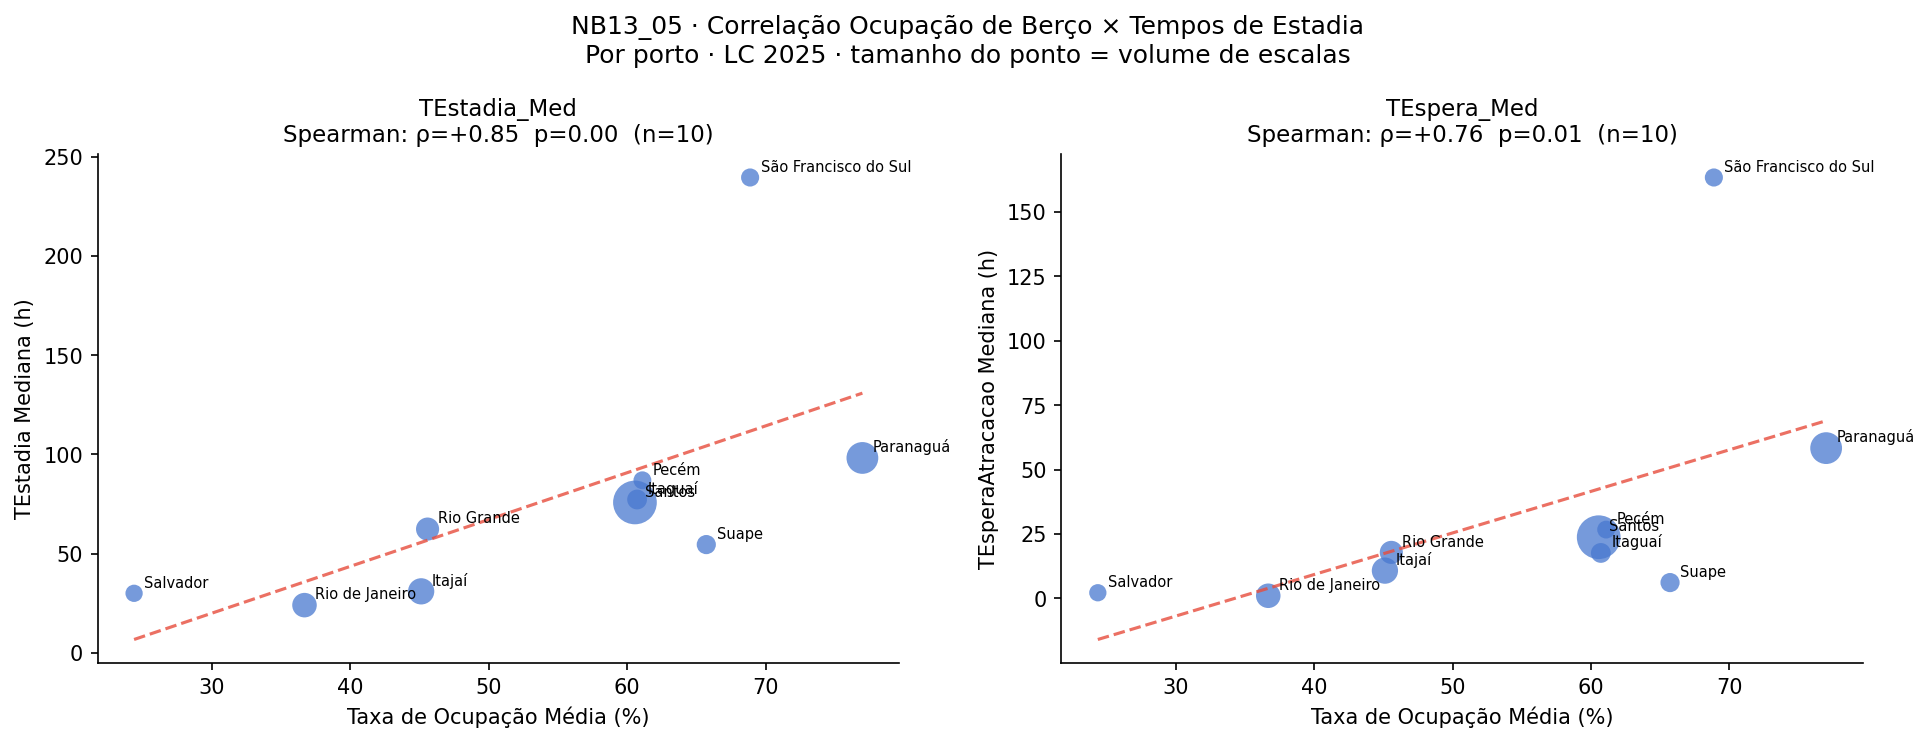

Salvo: nb13_05_scatter_ocupacao_testadia.png


In [16]:
# ── Figura nb13_05: Scatter taxa ocupação × TEsperaAtracacao ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_i, (y_col, y_label, rho, p_val) in enumerate([
    ('TEstadia_Med',  'TEstadia Mediana (h)',          rho_est, p_est),
    ('TEspera_Med',   'TEsperaAtracacao Mediana (h)',  rho_esp, p_esp),
]):
    ax = axes[ax_i]
    valid = corr_df.dropna(subset=['Taxa_Media_Pct', y_col])
    ax.scatter(valid['Taxa_Media_Pct'], valid[y_col],
               s=valid['N_Atr'] / valid['N_Atr'].max() * 400 + 40,
               color='#4878CF', alpha=0.75, edgecolors='none')

    # Linha de tendência
    if len(valid) >= 3:
        z = np.polyfit(valid['Taxa_Media_Pct'], valid[y_col], 1)
        x_line = np.linspace(valid['Taxa_Media_Pct'].min(), valid['Taxa_Media_Pct'].max(), 50)
        ax.plot(x_line, np.polyval(z, x_line), '--', color='#e74c3c', lw=1.5, alpha=0.8)

    for _, row in valid.iterrows():
        ax.annotate(row['Porto_Canon'], (row['Taxa_Media_Pct'], row[y_col]),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)

    rho_str = f'ρ={rho:+.2f}  p={p_val:.2f}' if not np.isnan(rho) else 'n insuf.'
    ax.set_xlabel('Taxa de Ocupação Média (%)', fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_title(f'{y_col}\nSpearman: {rho_str}  (n={len(valid)})', fontsize=11)

fig.suptitle('NB13_05 · Correlação Ocupação de Berço × Tempos de Estadia\n'
             'Por porto · LC 2025 · tamanho do ponto = volume de escalas', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb13_05_scatter_ocupacao_testadia.png', dpi=150)
plt.show()
print('Salvo: nb13_05_scatter_ocupacao_testadia.png')

---
## Parte 4 — Top Berços Saturados (Ranking Detalhado)

In [17]:
# ── Top 15 berços + TEstadia mediana ─────────────────────────────────────
top15_full = berco_kpi.head(15)[[
    'Nome_Berco','Porto','Taxa_Media_Pct','Taxa_Max_Mensal_Pct',
    'Dias_Acima_80','Dias_Acima_95','Mes_Pico','N_Atr','TEstadia_Med','Status'
]].copy()
top15_full['Nome_Berco'] = top15_full['Nome_Berco'].str[:35]

print('Top 15 Berços de Contentores por Taxa de Ocupação Média:')
print(top15_full.round(1).to_string(index=False))

Top 15 Berços de Contentores por Taxa de Ocupação Média:
                  Nome_Berco                Porto  Taxa_Media_Pct  Taxa_Max_Mensal_Pct  Dias_Acima_80  Dias_Acima_95 Mes_Pico  N_Atr  TEstadia_Med   Status
                Cais Público                Suape            97.3                100.0            344            335      Jan   87.0          28.6 Vermelho
                 Retroarea 2 São Francisco do Sul            96.0                 99.0            346            303      Out   66.0         207.7 Vermelho
                 Retroarea 1 São Francisco do Sul            95.3                 99.2            346            289      Nov   75.0         511.6 Vermelho
Corredor de Exportação Leste            Paranaguá            93.7                 97.6            342            247      Jan  116.0         345.5 Vermelho
Cais comercial do Porto Novo           Rio Grande            92.1                 98.5            313            287      Mar  163.0          96.7 Vermelho
       

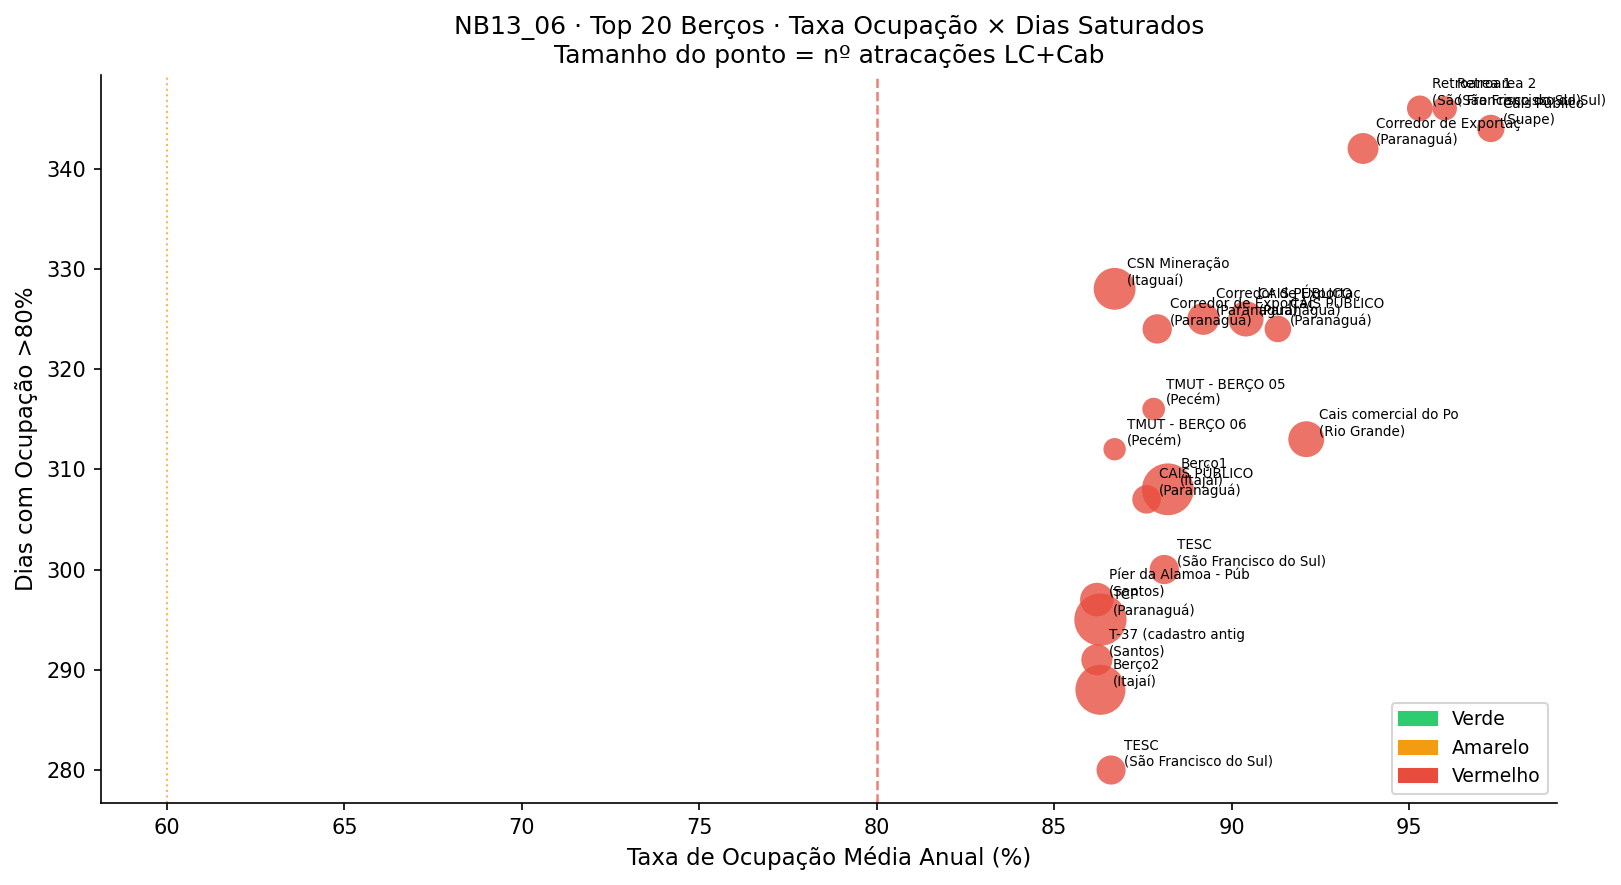

Salvo: nb13_06_bubble_bercos_saturados.png


In [18]:
# ── Figura nb13_06: Bubble chart Taxa × Dias_80 × N_Atr ──────────────────
fig, ax = plt.subplots(figsize=(11, 6))
top20 = berco_kpi.head(20).copy()
top20['Label_Short'] = top20['Nome_Berco'].str[:20]
top20['N_Atr_filled'] = top20['N_Atr'].fillna(0)

cores_scatter = [STATUS_COLORS[s] for s in top20['Status']]
sc = ax.scatter(
    top20['Taxa_Media_Pct'],
    top20['Dias_Acima_80'],
    s=top20['N_Atr_filled'] / (top20['N_Atr_filled'].max() + 1) * 600 + 30,
    c=cores_scatter, alpha=0.78, edgecolors='none'
)

for _, row in top20.iterrows():
    ax.annotate(f"{row['Label_Short']}\n({row['Porto']})",
                (row['Taxa_Media_Pct'], row['Dias_Acima_80']),
                textcoords='offset points', xytext=(6, 2), fontsize=6.5)

ax.axvline(THRESH_VERMELHO, color='#e74c3c', ls='--', lw=1.2, alpha=0.7)
ax.axvline(THRESH_AMARELO,  color='#f39c12', ls=':',  lw=1.0, alpha=0.7)

patches = [mpatches.Patch(color=v, label=k) for k, v in STATUS_COLORS.items()]
ax.legend(handles=patches, fontsize=9)
ax.set_xlabel('Taxa de Ocupação Média Anual (%)', fontsize=11)
ax.set_ylabel('Dias com Ocupação >80%', fontsize=11)
ax.set_title('NB13_06 · Top 20 Berços · Taxa Ocupação × Dias Saturados\n'
             'Tamanho do ponto = nº atracações LC+Cab', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb13_06_bubble_bercos_saturados.png', dpi=150)
plt.show()
print('Salvo: nb13_06_bubble_bercos_saturados.png')

---
## Parte 5 — Sazonalidade: Escalas vs Ocupação de Berço

In [19]:
# ── Escalas mensais por porto (LC+Cab) ────────────────────────────────────
atr_lccab2 = atr_raw[atr_raw[NAV_COL].isin(['Longo Curso','Cabotagem'])].copy()
atr_lccab2['Porto_Canon'] = atr_lccab2['Porto Atracação'].map(CONTAINER_PORTOS)
atr_lccab2 = atr_lccab2[atr_lccab2['Porto_Canon'].notna()]
atr_lccab2['Mes_num'] = pd.to_numeric(atr_lccab2['Mes'], errors='coerce')

escalas_mensais = (
    atr_lccab2.groupby(['Porto_Canon','Mes_num'])
    .size()
    .reset_index(name='N_Escalas')
)

# Normalizar dentro de cada porto para comparar forma da curva
for porto_c in escalas_mensais['Porto_Canon'].unique():
    mask = escalas_mensais['Porto_Canon'] == porto_c
    mx = escalas_mensais.loc[mask, 'N_Escalas'].max()
    escalas_mensais.loc[mask, 'Escalas_Norm'] = escalas_mensais.loc[mask, 'N_Escalas'] / mx * 100

# Normalizar taxa de ocupação da mesma forma
mensal_porto_norm = mensal_porto.copy()
for porto_c in mensal_porto_norm['Porto_Canon'].unique():
    mask = mensal_porto_norm['Porto_Canon'] == porto_c
    mx = mensal_porto_norm.loc[mask, 'taxa_media_mensal'].max()
    mensal_porto_norm.loc[mask, 'Taxa_Norm'] = mensal_porto_norm.loc[mask, 'taxa_media_mensal'] / mx * 100 if mx > 0 else 0

# Correlação por porto entre escalas normalizadas e taxa ocupação normalizada
print('=== Correlação mensal Escalas × Taxa_Ocupacao por porto ===')
corr_saz_rows = []
for porto_c in sorted(escalas_mensais['Porto_Canon'].unique()):
    esc = escalas_mensais[escalas_mensais['Porto_Canon']==porto_c][['Mes_num','Escalas_Norm']]
    ocp = mensal_porto_norm[mensal_porto_norm['Porto_Canon']==porto_c][['mes_num','Taxa_Norm']].rename(columns={'mes_num':'Mes_num'})
    merged_saz = esc.merge(ocp, on='Mes_num', how='inner')
    if len(merged_saz) >= 4:
        rho_saz, p_saz = stats.spearmanr(merged_saz['Escalas_Norm'], merged_saz['Taxa_Norm'])
        corr_saz_rows.append({'Porto': porto_c, 'Rho_Escalas_Ocupacao': round(rho_saz,2),
                               'P_value': round(p_saz,3), 'N_meses': len(merged_saz)})
        print(f'  {porto_c:25s}  ρ={rho_saz:+.2f}  p={p_saz:.3f}  n={len(merged_saz)}')
    else:
        print(f'  {porto_c:25s}  dados insuficientes')

corr_saz = pd.DataFrame(corr_saz_rows)

=== Correlação mensal Escalas × Taxa_Ocupacao por porto ===


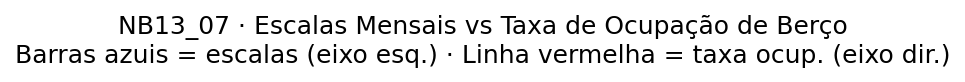

Salvo: nb13_07_sazonalidade_escalas_ocupacao.png


In [20]:
# ── Figura nb13_07: Sobreposição escalas × taxa ocupação ─────────────────
portos_plot7 = [p for p in porto_order_tax if p in escalas_mensais['Porto_Canon'].unique()][:6]
n_rows_p = max(1, (len(portos_plot7) + 1) // 2)

fig, axes = plt.subplots(n_rows_p, 2, figsize=(13, n_rows_p * 3.5))
axes = axes.flatten()

for i_p, porto_c in enumerate(portos_plot7):
    ax_sub = axes[i_p]
    esc = escalas_mensais[escalas_mensais['Porto_Canon']==porto_c].sort_values('Mes_num')
    ocp = mensal_porto[mensal_porto['Porto_Canon']==porto_c].sort_values('mes_num')

    ax2 = ax_sub.twinx()
    ax_sub.bar(esc['Mes_num'], esc['N_Escalas'], color='#4878CF', alpha=0.45, label='Escalas')
    ax2.plot(ocp['mes_num'], ocp['taxa_media_mensal'],
             color='#e74c3c', marker='o', linewidth=2, label='Taxa Ocup.')
    ax2.axhline(THRESH_VERMELHO, color='#e74c3c', ls='--', lw=0.8, alpha=0.5)

    ax_sub.set_xticks(list(MES_LABEL.keys()))
    ax_sub.set_xticklabels(list(MES_LABEL.values()), fontsize=7)
    ax_sub.set_ylabel('Nº Escalas', fontsize=8, color='#4878CF')
    ax2.set_ylabel('Taxa Ocup. (%)', fontsize=8, color='#e74c3c')
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax_sub.set_title(porto_c, fontsize=10)

    # Correlação no título
    row_corr = corr_saz[corr_saz['Porto']==porto_c]
    if len(row_corr) > 0:
        rho_val = row_corr['Rho_Escalas_Ocupacao'].values[0]
        ax_sub.set_title(f'{porto_c}  (ρ={rho_val:+.2f})', fontsize=10)

# Esconder subplots extras
for j in range(len(portos_plot7), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('NB13_07 · Escalas Mensais vs Taxa de Ocupação de Berço\n'
             'Barras azuis = escalas (eixo esq.) · Linha vermelha = taxa ocup. (eixo dir.)', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb13_07_sazonalidade_escalas_ocupacao.png', dpi=150)
plt.show()
print('Salvo: nb13_07_sazonalidade_escalas_ocupacao.png')

---
## Parte 6 — Exportação CSV

In [21]:
# ── CSV 1: KPIs por berço ──────────────────────────────────────────────────
berco_kpi.to_csv(CSV_DIR + 'ocupacao_bercos_kpi_2025.csv', index=False, encoding='utf-8-sig')
print('Salvo: ocupacao_bercos_kpi_2025.csv')

# ── CSV 2: Evolução mensal por porto ──────────────────────────────────────
mensal_porto.to_csv(CSV_DIR + 'ocupacao_mensal_porto_2025.csv', index=False, encoding='utf-8-sig')
print('Salvo: ocupacao_mensal_porto_2025.csv')

# ── CSV 3: Correlação ocupação × TEstadia por porto ───────────────────────
corr_df.to_csv(CSV_DIR + 'ocupacao_testadia_porto_2025.csv', index=False, encoding='utf-8-sig')
print('Salvo: ocupacao_testadia_porto_2025.csv')

# ── CSV 4: Sazonalidade escalas por porto ─────────────────────────────────
escalas_mensais.to_csv(CSV_DIR + 'escalas_mensais_porto_2025.csv', index=False, encoding='utf-8-sig')
print('Salvo: escalas_mensais_porto_2025.csv')

# ── CSV 5: Correlação sazonalidade ────────────────────────────────────────
if len(corr_saz) > 0:
    corr_saz.to_csv(CSV_DIR + 'corr_sazonalidade_escalas_ocupacao_2025.csv', index=False, encoding='utf-8-sig')
    print('Salvo: corr_sazonalidade_escalas_ocupacao_2025.csv')

print('\nExportação concluída.')

Salvo: ocupacao_bercos_kpi_2025.csv
Salvo: ocupacao_mensal_porto_2025.csv
Salvo: ocupacao_testadia_porto_2025.csv


Salvo: escalas_mensais_porto_2025.csv

Exportação concluída.


---
## Limitações Metodológicas

1. **Filtro de berços container por porto:** classificação aproximada por nome do porto — berços mistos (contentores + granéis) podem estar incluídos (sobrestima saturação) ou excluídos (subestima). O filtro por keyword de terminal complementa mas não elimina a ambiguidade.

2. **Join via Atracacao como bridge:** IDBerco em Relatorio_Berco usa formato diferente (BRPA2145001 vs SSZ0651). O mapeamento via Atracacao cobre ~70% dos registos de Taxa_Ocupacao; os restantes 30% são berços que não tiveram atracações em 2025 ou usam código não harmonizado.

3. **Taxa > 100%:** não detectada neste dataset. Caso fosse detectada, indicaria sobreposição de registos (dois navios no mesmo berço simultaneamente) ou erro de granularidade temporal.

4. **Correlação Spearman (Parte 3):** n de portos é pequeno (≤12). Correlação indicativa — não suficiente para inferência causal. Um porto com alta ocupação pode ter baixa TEstadia se opera navios menores/mais rápidos.

5. **Dados apenas 2025:** sem comparação inter-anual. A identificação de sazonalidade é descritiva — não é possível distinguir padrão estrutural de variação pontual de 2025.

6. **TO vs TOCC:** Taxa_Ocupacao inclui tempo de espera no berço sem operação de carga. Taxa_Ocupacao_Com_Carga é mais restritiva. A diferença indica a proporção de tempo improdutivo no berço — relevante para gestão de capacidade mas não calculada explicitamente aqui.